#  Titanic survival Analysis Project

# Importing necessesary library.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")
%matplotlib inline

# To know the present working directory.

In [5]:
pwd

'c:\\Users\\MOHIT\\data science'

# Load dataset

In [6]:
titanic_data = pd.read_csv("Titanic-Dataset.csv")
titanic_data #data we get by reading 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# Data understanding

In [7]:
titanic_data.columns #columns head or you can say the heading of the data we have 

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [8]:
titanic_data.shape #to get the no. of (rows,columns)

(891, 12)

In [9]:
titanic_data.info() # to get all the detail of the data like rows&columns, no. of missing data,dtypes=,memory usage

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [10]:
titanic_data.head(12) # top 10 of the data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [11]:
titanic_data.tail(15) # bottom 15 of the data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
876,877,0,3,"Gustafsson, Mr. Alfred Ossian",male,20.0,0,0,7534,9.8458,NaN,S
877,878,0,3,"Petroff, Mr. Nedelio",male,19.0,0,0,349212,7.8958,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
880,881,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0,0,1,230433,26.0000,NaN,S
881,882,0,3,"Markun, Mr. Johann",male,33.0,0,0,349257,7.8958,NaN,S
882,883,0,3,"Dahlberg, Miss. Gerda Ulrika",female,22.0,0,0,7552,10.5167,NaN,S
883,884,0,2,"Banfield, Mr. Frederick James",male,28.0,0,0,C.A./SOTON 34068,10.5000,NaN,S
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q


In [12]:
titanic_data.sample(8) #give random 8 rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
558,559,1,1,"Taussig, Mrs. Emil (Tillie Mandelbaum)",female,39.0,1,1,110413,79.6500,E67,S
771,772,0,3,"Jensen, Mr. Niels Peder",male,48.0,0,0,350047,7.8542,NaN,S
535,536,1,2,"Hart, Miss. Eva Miriam",female,7.0,0,2,F.C.C. 13529,26.2500,NaN,S
328,329,1,3,"Goldsmith, Mrs. Frank John (Emily Alice Brown)",female,31.0,1,1,363291,20.5250,NaN,S
423,424,0,3,"Danbom, Mrs. Ernst Gilbert (Anna Sigrid Maria ...",female,28.0,1,1,347080,14.4000,NaN,S
329,330,1,1,"Hippach, Miss. Jean Gertrude",female,16.0,0,1,111361,57.9792,B18,C
472,473,1,2,"West, Mrs. Edwy Arthur (Ada Mary Worth)",female,33.0,1,2,C.A. 34651,27.7500,NaN,S
505,506,0,1,"Penasco y Castellana, Mr. Victor de Satode",male,18.0,1,0,PC 17758,108.9000,C65,C


In [13]:
titanic_data.dtypes # tell what dtype each columns contain

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [14]:
titanic_data.describe() # its tells the count of the value,mean, std,25%,50%,75%,min,max

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [15]:
titanic_data.describe().T # transpose of data for better understanding of it

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


# -Missing Value analysis

In [16]:
#to find missing value of each columns
titanic_data.isnull().sum() #also can use isna(),, use of sum() to get total no. of missing value in each columns

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [17]:
#Alternate method to find which columns have missing value 
missing_val= [i for i in titanic_data.columns 
                        if titanic_data[i].isna().sum()>0]
missing_val

['Age', 'Cabin', 'Embarked']

In [18]:
#To know which columns contain the int & float values 
num_col =[i for i in titanic_data.columns 
              if titanic_data[i].dtypes !='object']
num_col

['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

In [19]:
#To know which columns contain the object values
cat_col=[k for k in titanic_data.columns 
           if titanic_data[k].dtypes == "object"]
cat_col

['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']

In [20]:
#To assigne data according to the two different data types back according to the heading
num_data =titanic_data[num_col]
cat_data = titanic_data[cat_col]

In [21]:
num_data # now we have numerical data and there columns head 

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500
...,...,...,...,...,...,...,...
886,887,0,2,27.0,0,0,13.0000
887,888,1,1,19.0,0,0,30.0000
888,889,0,3,NaN,1,2,23.4500
889,890,1,1,26.0,0,0,30.0000


In [22]:
cat_data # here the categorical data 

,Name,Sex,Ticket,Cabin,Embarked
0,"Braund, Mr. Owen Harris",male,A/5 21171,NaN,S
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,PC 17599,C85,C
2,"Heikkinen, Miss. Laina",female,STON/O2. 3101282,NaN,S
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,113803,C123,S
4,"Allen, Mr. William Henry",male,373450,NaN,S
...,...,...,...,...,...
886,"Montvila, Rev. Juozas",male,211536,NaN,S
887,"Graham, Miss. Margaret Edith",female,112053,B42,S
888,"Johnston, Miss. Catherine Helen ""Carrie""",female,W./C. 6607,NaN,S
889,"Behr, Mr. Karl Howell",male,111369,C148,C


# -Data Cleaning(For Analysis)

In [23]:
#Fill Age with median bcoz median does not get affected by the outliers.(childern or senior age)
titanic_data['Age'].fillna(titanic_data['Age'].median(),inplace=True)

In [24]:
#fill embarked with mode
titanic_data['Embarked'].fillna(titanic_data['Embarked'].mode()[0], inplace=True)

In [25]:
#drop too more 50% missing data colums and unecessary data
titanic_data=titanic_data.drop(['Cabin','PassengerId'],axis=1) #To drop a column from a variable

# -Univariate analysis(single variable/columns)

<Axes: xlabel='Survived', ylabel='count'>

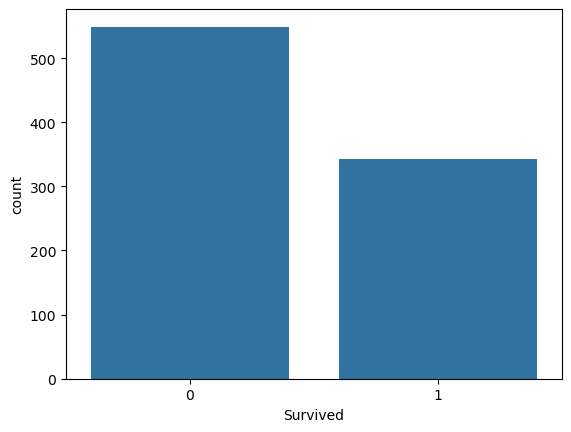

In [26]:
#survival distribution
sns.countplot(x='Survived',data=titanic_data) #countplot

**Observed :** number of people survived:1 , not survived: 0
- number of non survial is higher than non survial 

<Axes: xlabel='Sex', ylabel='count'>

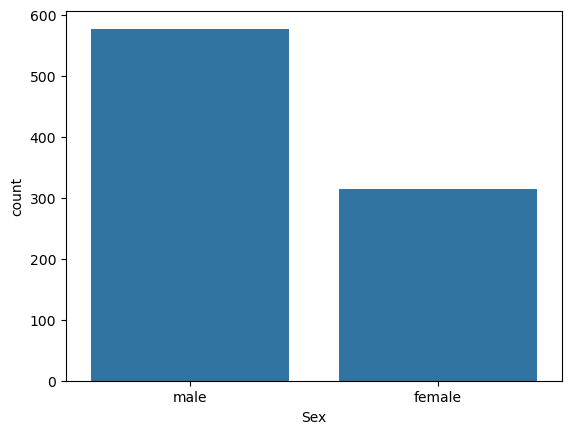

In [27]:
#  distribution 
sns.countplot(x='Sex',data=titanic_data)

**Observation:** number of male and female ratio. **number of male is higher then female in the ship.**

<Axes: xlabel='Pclass', ylabel='count'>

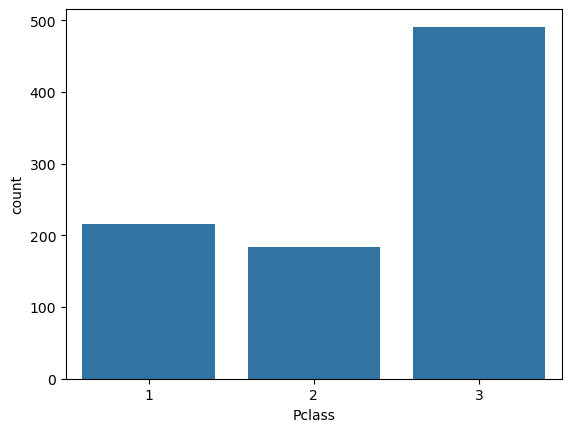

In [28]:
# Passenger class distribution 
sns.countplot(x='Pclass',data=titanic_data)

**Observation** number of passenger in 1st,2nd and 3rd class.
- the majority of ppl pay for 3rd class as cheaper Fare.

<Axes: xlabel='Age', ylabel='Count'>

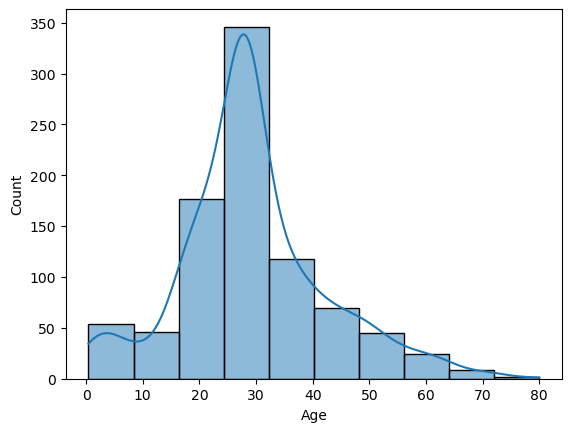

In [29]:
# Age distribution
sns.histplot(titanic_data['Age'],bins=10,kde=True)

**Observation** majority of ppl fall on  25-35age.
- here we can say the majority of paggenger is younger. and very less old and childern present on the ship.

<Axes: xlabel='Fare', ylabel='Count'>

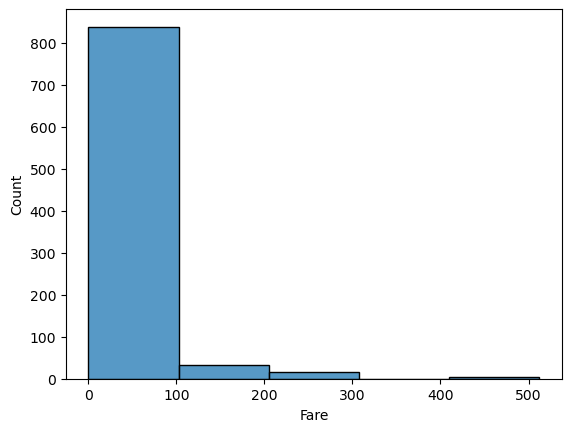

In [80]:
# Fare 
sns.histplot(titanic_data['Fare'],bins=5)


Text(0.5, 1.0, 'Fare distribution')

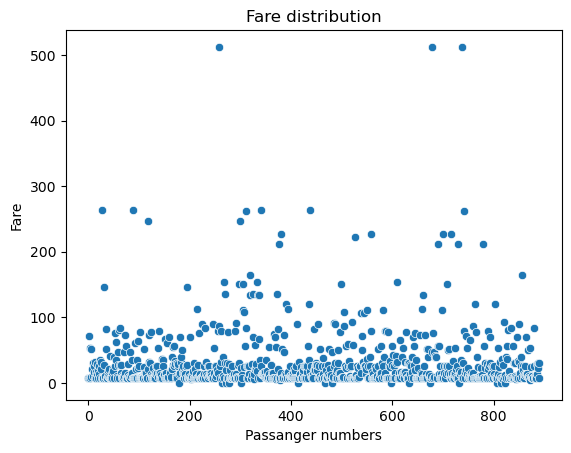

In [81]:
#for more better understanding and to know majority of ticket sold at.
sns.scatterplot(data=titanic_data,x=titanic_data.index, y="Fare")
plt.xlabel('Passanger numbers')
plt.title('Fare distribution')

**Obervation** majority of the ppl paid very less. but here some of the ppl have paid as higher as 500$.

# -BIVARIATE ANALYSIS

**Going to observe:** Survial vs gender /
Survival vs passanger class / Survival vs Age / Survival vs Fare

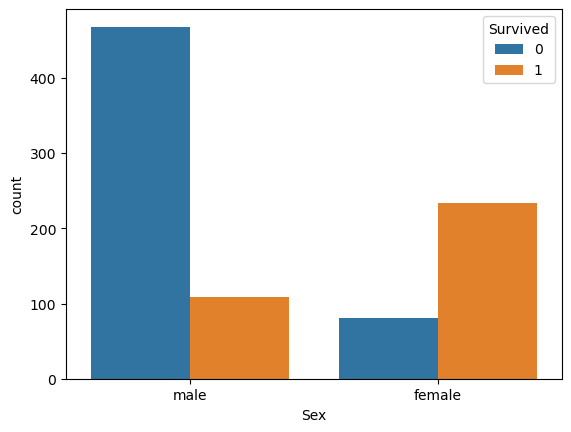

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

In [ ]:
#Survival vs gender 
sns.countplot(x='Sex',hue='Survived',data=titanic_data)
plt.show()

titanic_data.groupby('Sex')['Survived'].mean()*100 ## 

**Observed**  As we can see female have more survival ratio then male.

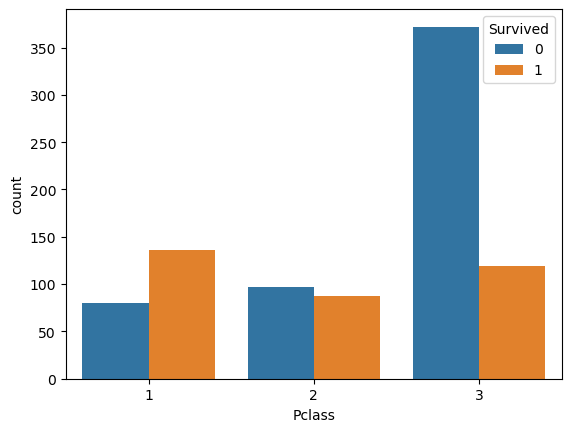

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

In [61]:
# Survival vs passanger class
sns.countplot(x='Pclass', hue='Survived',data=titanic_data)
plt.show()
titanic_data.groupby('Pclass')['Survived'].mean()*100

**Observed** survival of the passenger according to the passenger calss.

**as we can see 1st class have more survival ratio as comapre to 3rd class**

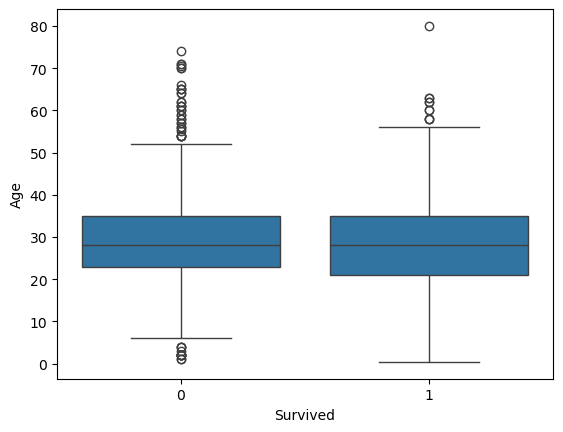

In [64]:
#Survival vs Age
sns.boxplot(x='Survived',y='Age',data=titanic_data)
plt.show()

**Observation** As we can see of surviving for younger ppl is more than the older ppl.

<Axes: xlabel='Survived', ylabel='Fare'>

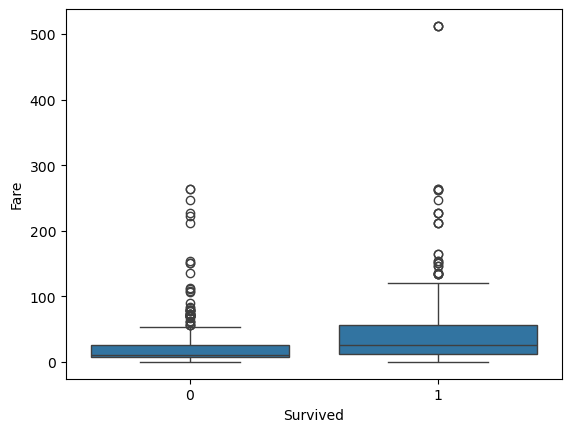

In [68]:
#Survival vs Fare
sns.boxplot(x='Survived',y='Fare',data=titanic_data)

**Observed** the most of the ppl pay lower Fare. 
**Passengers who paid higher fares had a higher chance of survival.**

Text(0.5, 1.0, 'Survuval vs Fare')

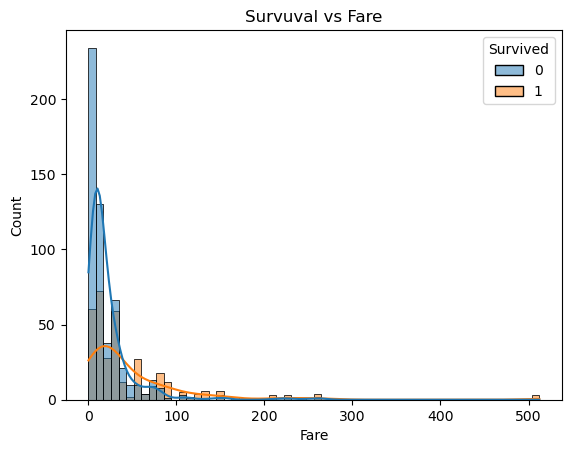

In [84]:
sns.histplot(data=titanic_data,x='Fare',hue='Survived',kde=True)
plt.title('Survuval vs Fare')

# -To get correlation of the Data


In [36]:
#
num_data.corr() # to know relation positive and negative relation b/w columns data. 0 means no relation..

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [37]:
#
num_data.cov() #to know the relation b/w positive and negative only.

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,66231.000000,-0.626966,-7.561798,138.696504,-16.325843,-0.342697,161.883369
Survived,-0.626966,0.236772,-0.137703,-0.551296,-0.018954,0.032017,6.221787
Pclass,-7.561798,-0.137703,0.699015,-4.496004,0.076599,0.012429,-22.830196
Age,138.696504,-0.551296,-4.496004,211.019125,-4.163334,-2.344191,73.849030
SibSp,-16.325843,-0.018954,0.076599,-4.163334,1.216043,0.368739,8.748734
Parch,-0.342697,0.032017,0.012429,-2.344191,0.368739,0.649728,8.661052
Fare,161.883369,6.221787,-22.830196,73.849030,8.748734,8.661052,2469.436846


# -Multivarriate Analysis

<Axes: >

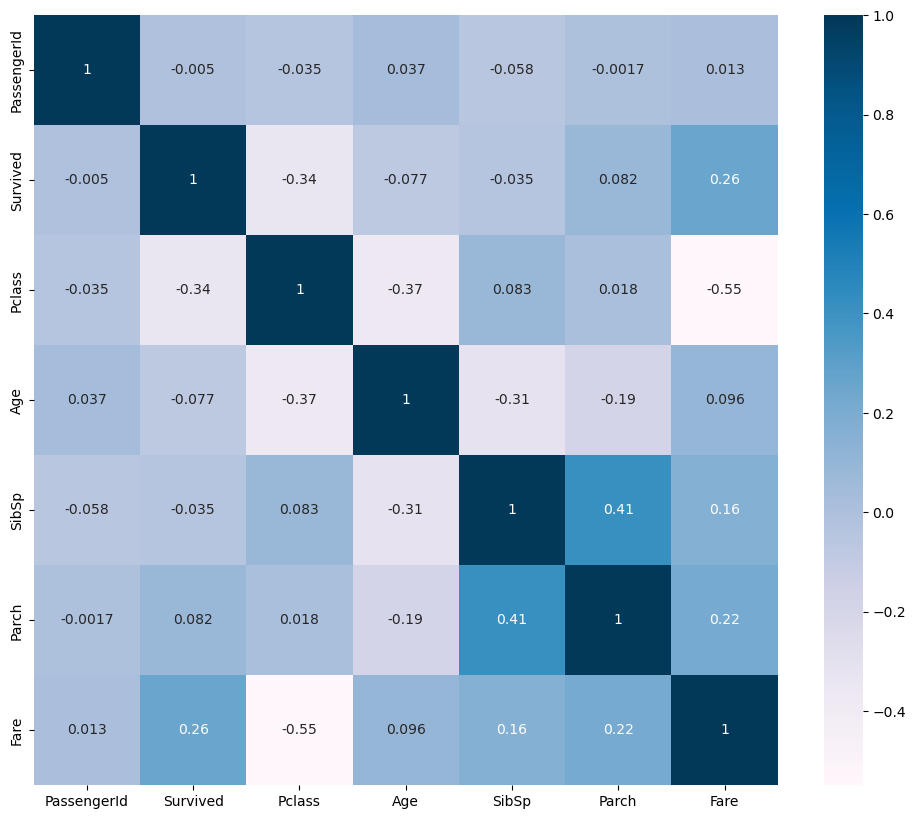

In [38]:
# heatmap to find the relationship of the numeric data
plt.figure(figsize=(12,10))
sns.heatmap(num_data.corr(),cmap='PuBu',annot=True)

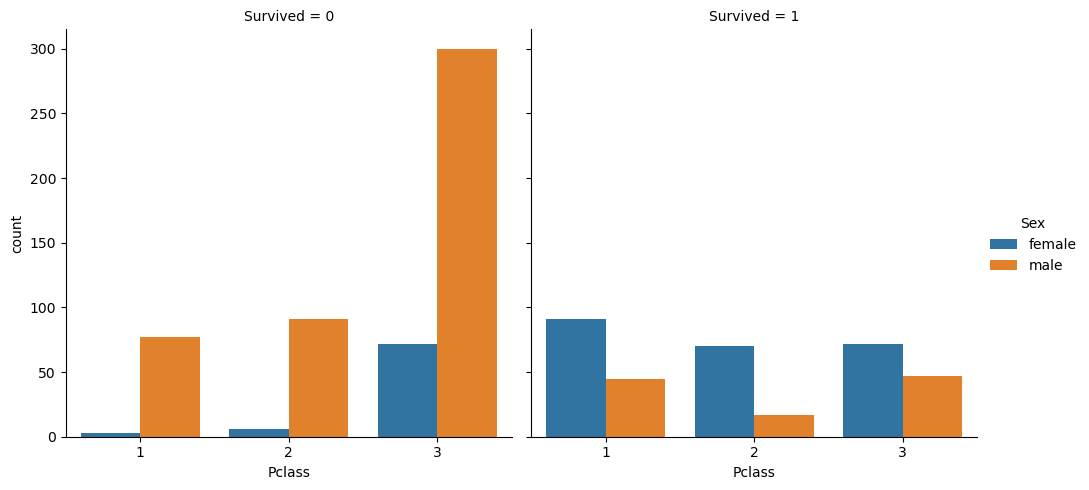

In [39]:
#catplot of survived vs(gender & pclass) 
sns.catplot(data=titanic_data ,x="Pclass",hue='Sex', col='Survived',kind="count")


**Obeserved** the survial of the male is lower comparison to female from all the classes... 

Text(0.5, 1.0, 'Age & class affecting Survival')

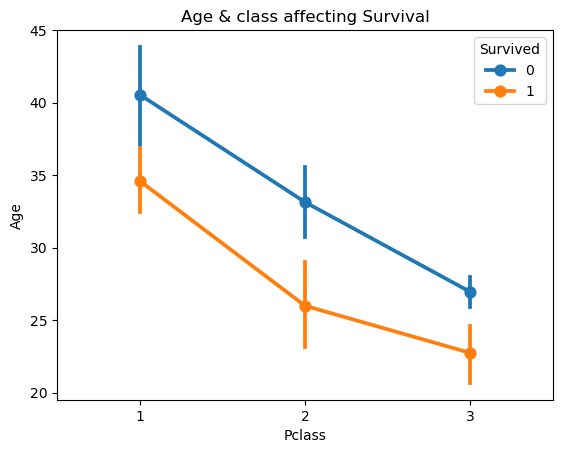

In [40]:
# pointplot of survival vs(Age & Pclass)
sns.pointplot(data= titanic_data,x='Pclass',hue='Survived', y='Age')
plt.title('Age & class affecting Survival')

**Observed** The average age of survived ppl is younger side from all the class...
- Younger ppl have better chances of survial then older ppl

# Key Insights 
- **Strong Survival Factors**
- Gender(female survived more)
- Fare(higer fare = hinger survival)
- Passenger class(1st class have higher survial then 3rd class)

- **moderate Survival Factors** 
- Age 

# ML Part 

In [41]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler #for the standarization and normalization of data

In [42]:
# methode 1: to coverte the numerical data
standard =StandardScaler()
standard_scaled= standard.fit_transform(num_data)
standard_scaled

array([[-1.73010796, -0.78927234,  0.82737724, ...,  0.43279337,
        -0.47367361, -0.50244517],
       [-1.72622007,  1.2669898 , -1.56610693, ...,  0.43279337,
        -0.47367361,  0.78684529],
       [-1.72233219,  1.2669898 ,  0.82737724, ..., -0.4745452 ,
        -0.47367361, -0.48885426],
       ...,
       [ 1.72233219, -0.78927234,  0.82737724, ...,  0.43279337,
         2.00893337, -0.17626324],
       [ 1.72622007,  1.2669898 , -1.56610693, ..., -0.4745452 ,
        -0.47367361, -0.04438104],
       [ 1.73010796, -0.78927234,  0.82737724, ..., -0.4745452 ,
        -0.47367361, -0.49237783]], shape=(891, 7))

In [43]:
#methode 2: to normalize the numerical data using minmax
minmax = MinMaxScaler()
minmax_scaled = minmax.fit_transform(num_data)
minmax_scaled

array([[0.        , 0.        , 1.        , ..., 0.125     , 0.        ,
        0.01415106],
       [0.0011236 , 1.        , 0.        , ..., 0.125     , 0.        ,
        0.13913574],
       [0.00224719, 1.        , 1.        , ..., 0.        , 0.        ,
        0.01546857],
       ...,
       [0.99775281, 0.        , 1.        , ..., 0.125     , 0.33333333,
        0.04577135],
       [0.9988764 , 1.        , 0.        , ..., 0.        , 0.        ,
        0.0585561 ],
       [1.        , 0.        , 1.        , ..., 0.        , 0.        ,
        0.01512699]], shape=(891, 7))

In [44]:
# dataframe of the standard and normilze data respectively.
df_standard_scaled= pd.DataFrame(minmax_scaled,columns=num_data.columns)
df_minmax_scaled = pd.DataFrame(minmax_scaled,columns=num_data.columns)
df_standard_scaled

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,0.000000,0.0,1.0,0.271174,0.125,0.000000,0.014151
1,0.001124,1.0,0.0,0.472229,0.125,0.000000,0.139136
2,0.002247,1.0,1.0,0.321438,0.000,0.000000,0.015469
3,0.003371,1.0,0.0,0.434531,0.125,0.000000,0.103644
4,0.004494,0.0,1.0,0.434531,0.000,0.000000,0.015713
...,...,...,...,...,...,...,...
886,0.995506,0.0,0.5,0.334004,0.000,0.000000,0.025374
887,0.996629,1.0,0.0,0.233476,0.000,0.000000,0.058556
888,0.997753,0.0,1.0,NaN,0.125,0.333333,0.045771
889,0.998876,1.0,0.0,0.321438,0.000,0.000000,0.058556


In [45]:
df_minmax_scaled

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,0.000000,0.0,1.0,0.271174,0.125,0.000000,0.014151
1,0.001124,1.0,0.0,0.472229,0.125,0.000000,0.139136
2,0.002247,1.0,1.0,0.321438,0.000,0.000000,0.015469
3,0.003371,1.0,0.0,0.434531,0.125,0.000000,0.103644
4,0.004494,0.0,1.0,0.434531,0.000,0.000000,0.015713
...,...,...,...,...,...,...,...
886,0.995506,0.0,0.5,0.334004,0.000,0.000000,0.025374
887,0.996629,1.0,0.0,0.233476,0.000,0.000000,0.058556
888,0.997753,0.0,1.0,NaN,0.125,0.333333,0.045771
889,0.998876,1.0,0.0,0.321438,0.000,0.000000,0.058556


In [46]:
num_data.cov() #to know the relation b/w positive and negative only.

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,66231.000000,-0.626966,-7.561798,138.696504,-16.325843,-0.342697,161.883369
Survived,-0.626966,0.236772,-0.137703,-0.551296,-0.018954,0.032017,6.221787
Pclass,-7.561798,-0.137703,0.699015,-4.496004,0.076599,0.012429,-22.830196
Age,138.696504,-0.551296,-4.496004,211.019125,-4.163334,-2.344191,73.849030
SibSp,-16.325843,-0.018954,0.076599,-4.163334,1.216043,0.368739,8.748734
Parch,-0.342697,0.032017,0.012429,-2.344191,0.368739,0.649728,8.661052
Fare,161.883369,6.221787,-22.830196,73.849030,8.748734,8.661052,2469.436846


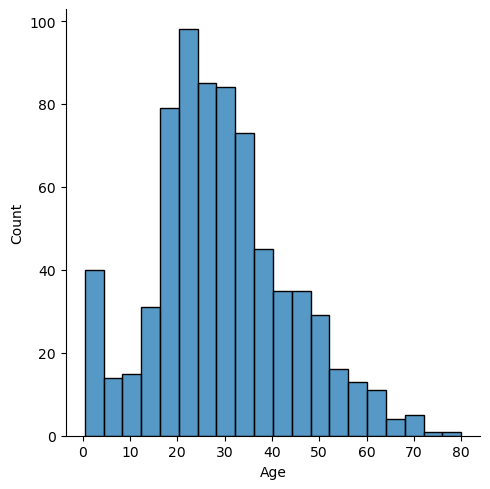

In [47]:
sns.displot(num_data["Age"] )

<Axes: xlabel='count', ylabel='Sex'>

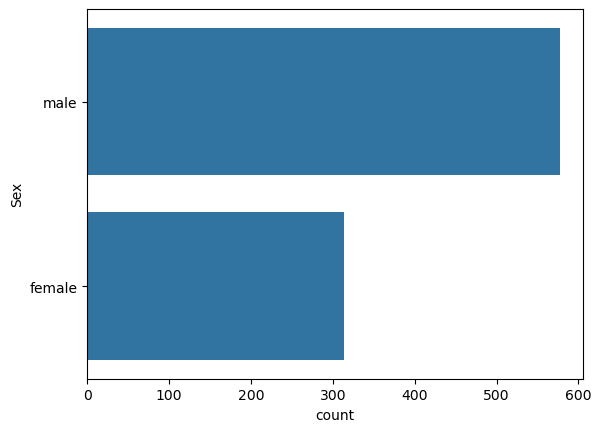

In [48]:
sns.countplot(cat_data["Sex"]) # to get the number of repeated character 

<Axes: >

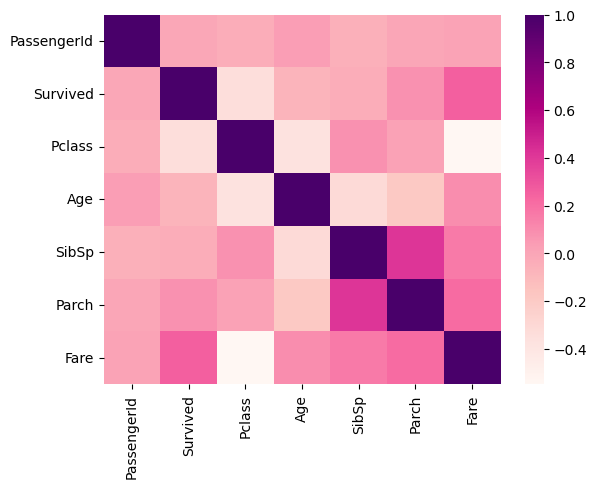

In [49]:
plt.Figure(figsize=(10,8)) #heatmap graphs for relation of num_data. cmap= for the colour
sns.heatmap(num_data.corr(),cmap="RdPu")

In [50]:
## now for the categorical data lets see the categorial data coloumns
cat_col

['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']

In [51]:
cat_data

,Name,Sex,Ticket,Cabin,Embarked
0,"Braund, Mr. Owen Harris",male,A/5 21171,NaN,S
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,PC 17599,C85,C
2,"Heikkinen, Miss. Laina",female,STON/O2. 3101282,NaN,S
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,113803,C123,S
4,"Allen, Mr. William Henry",male,373450,NaN,S
...,...,...,...,...,...
886,"Montvila, Rev. Juozas",male,211536,NaN,S
887,"Graham, Miss. Margaret Edith",female,112053,B42,S
888,"Johnston, Miss. Catherine Helen ""Carrie""",female,W./C. 6607,NaN,S
889,"Behr, Mr. Karl Howell",male,111369,C148,C


In [52]:
cat_data.isnull().sum() # to get the total numbers of missing value in the columns

Name          0
Sex           0
Ticket        0
Cabin       687
Embarked      2
dtype: int64

In [53]:
#To fill the missing value with most repeated value in the columns with the help of "mode"
x=cat_data.fillna(cat_data.mode().iloc()) # to fill the missing value
x

,Name,Sex,Ticket,Cabin,Embarked
0,"Braund, Mr. Owen Harris",male,A/5 21171,<pandas.core.indexing._iLocIndexer object at 0...,S
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,PC 17599,C85,C
2,"Heikkinen, Miss. Laina",female,STON/O2. 3101282,<pandas.core.indexing._iLocIndexer object at 0...,S
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,113803,C123,S
4,"Allen, Mr. William Henry",male,373450,<pandas.core.indexing._iLocIndexer object at 0...,S
...,...,...,...,...,...
886,"Montvila, Rev. Juozas",male,211536,<pandas.core.indexing._iLocIndexer object at 0...,S
887,"Graham, Miss. Margaret Edith",female,112053,B42,S
888,"Johnston, Miss. Catherine Helen ""Carrie""",female,W./C. 6607,<pandas.core.indexing._iLocIndexer object at 0...,S
889,"Behr, Mr. Karl Howell",male,111369,C148,C


In [54]:
x.isnull().sum()

Name        0
Sex         0
Ticket      0
Cabin       0
Embarked    0
dtype: int64

In [55]:
#method 1 : by using get dummies/ one hot encoding(pandas) convert the cate data to 0,1 
x_encoded = pd.get_dummies(x,drop_first=True)
x_encoded

,"Name_Abbott, Mr. Rossmore Edward","Name_Abbott, Mrs. Stanton (Rosa Hunt)","Name_Abelson, Mr. Samuel","Name_Abelson, Mrs. Samuel (Hannah Wizosky)","Name_Adahl, Mr. Mauritz Nils Martin","Name_Adams, Mr. John","Name_Ahlin, Mrs. Johan (Johanna Persdotter Larsson)","Name_Aks, Mrs. Sam (Leah Rosen)","Name_Albimona, Mr. Nassef Cassem","Name_Alexander, Mr. William",...,Cabin_F G73,Cabin_F2,Cabin_F33,Cabin_F38,Cabin_F4,Cabin_G6,Cabin_T,Embarked_C,Embarked_Q,Embarked_S
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
887,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
888,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
889,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
